## Black-Scholes Model and Volatility Smile Analysis

Task 2.1: Implement the Black-Scholes Formula:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import griddata


def bs_price(S, K, T, r, sigma, option_type='call', q=0.013):
    """
    Black-Scholes price for a European option with continuous dividend yield q.

    Parameters:
    S - spot price
    K - strike price
    T - time to maturity (in years)
    r - risk-free rate
    sigma - volatility
    option_type - 'call' or 'put'
    q - continuous dividend yield (default 0.013 for SPY / trailing 12-month dividend yield SPY ≈ 1.3%)
    """

    if T < 1e-10:
        if option_type == "call":
            return max(S - K, 0.0)
        else:
            return max(K - S, 0.0)
        
    F = S * np.exp(-q * T)  # dividend-adjusted forward

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = F * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - F * norm.cdf(-d1)
        
    return price

Test on simple cases

In [3]:
print("Part 1: Black-Scholes — Test Cases")

# Test case 1: ATM option
c1 = bs_price(S=100, K=100, T=1.0, r=0.05, sigma=0.20, option_type="call", q=0.0)
p1 = bs_price(S=100, K=100, T=1.0, r=0.05, sigma=0.20, option_type="put", q=0.0)
print("\nTest 1: ATM option (S=100, K=100, T=1, r=5%, sigma=20%)")
print(f"Call = {c1:.4f} (expected ≈ 10.4506)")
print(f"Put  = {p1:.4f} (expected ≈  5.5735)")

# Test case 2: deep ITM call
c2 = bs_price(S=150, K=100, T=1.0, r=0.05, sigma=0.20, option_type="call", q=0.0)
print("\nTest 2: Deep ITM call (S=150, K=100, T=1, r=5%, sigma=20%)")
print(f"Call = {c2:.4f} (should be ≈ S - K*e^(-rT) = {150 - 100*np.exp(-0.05):.4f})")

# Test case 3: deep OTM call => near zero
c3 = bs_price(S=100, K=200, T=0.25, r=0.05, sigma=0.20, option_type="call", q=0.0)
print("\nTest 3: Deep OTM call (S=100, K=200, T=0.25, r=5%, sigma=20%)")
print(f"Call = {c3:.6f} (should be ≈ 0)")

# Test case 4: T => 0 should give intrinsic value
c4 = bs_price(S=105, K=100, T=0.001, r=0.05, sigma=0.20, option_type="call", q=0.0)
print("\nTest 4: Near-expiry ITM call (S=105, K=100, T≈0)")
print(f"Call = {c4:.4f} (intrinsic = {max(105-100,0):.4f})")

# Test case 5: put-call parity on test data
#   C - P = S - K * e^(-rT)
parity_lhs = c1 - p1
parity_rhs = 100 - 100 * np.exp(-0.05)
print("\nTest 5: Put-call parity check (test case 1)")
print(f"C - P = {parity_lhs:.4f}")
print(f"S - Ke^-rT = {parity_rhs:.4f}")
print(f"Difference = {abs(parity_lhs - parity_rhs):.2e}")

Part 1: Black-Scholes — Test Cases

Test 1: ATM option (S=100, K=100, T=1, r=5%, sigma=20%)
Call = 10.4506 (expected ≈ 10.4506)
Put  = 5.5735 (expected ≈  5.5735)

Test 2: Deep ITM call (S=150, K=100, T=1, r=5%, sigma=20%)
Call = 54.9701 (should be ≈ S - K*e^(-rT) = 54.8771)

Test 3: Deep OTM call (S=100, K=200, T=0.25, r=5%, sigma=20%)
Call = 0.000000 (should be ≈ 0)

Test 4: Near-expiry ITM call (S=105, K=100, T≈0)
Call = 5.0050 (intrinsic = 5.0000)

Test 5: Put-call parity check (test case 1)
C - P = 4.8771
S - Ke^-rT = 4.8771
Difference = 0.00e+00


Put-Call Parity on Real SPY Data

- Put-call parity for European options:
- C - P = Se^(-qT) - Ke^(-rT)

In [4]:
df = pd.read_csv("data/spy_options_enriched.csv")

# Mid-price
df['mid'] = (df['bid'] + df['ask']) / 2

# Split calls and puts, merge on (expiry, strike)
calls = df[df['option_type'] == 'call'][['expiry', 'strike', 'mid', 'T', 'S', 'r']].copy()
puts  = df[df['option_type'] == 'put'][['expiry', 'strike', 'mid']].copy()

calls.columns = ['expiry', 'strike', 'C_mid', 'T', 'S', 'r']
puts.columns  = ['expiry', 'strike', 'P_mid']

pairs = calls.merge(puts, on=['expiry', 'strike'])

# Filter: keep only pairs where both mid prices are positive
pairs = pairs[(pairs['C_mid'] > 0) & (pairs['P_mid'] > 0)].copy()

# Compute parity
pairs['lhs'] = pairs['C_mid'] - pairs['P_mid'] # C - P
q = 0.013  # SPY continuous dividend yield
pairs['rhs'] = pairs['S'] * np.exp(-q * pairs['T']) - pairs['strike'] * np.exp(-pairs['r'] * pairs['T'])  # Se^-qT - Ke^-rT
pairs['parity_error'] = pairs['lhs'] - pairs['rhs']
pairs['parity_error_pct'] = pairs['parity_error'].abs() / pairs['S'] * 100

print(f"\nMatched call-put pairs: {len(pairs)}")
print("\nParity error (C - P) vs (Se^-qT - Ke^-rT):")
print(f"Mean absolute error: ${pairs['parity_error'].abs().mean():.4f}")
print(f"Median absolute error: ${pairs['parity_error'].abs().median():.4f}")
print(f"Max absolute error: ${pairs['parity_error'].abs().max():.4f}")
print(f"Mean error (% of S): {pairs['parity_error_pct'].mean():.4f}%")

# Per-expiry
print("\nPer-expiry summary:")
print(f"{'Expiry':<14} {'Pairs':>5} {'Mean |err|':>11} {'Median |err|':>13} {'Mean %':>8}")
for exp in sorted(pairs['expiry'].unique()):
    sub = pairs[pairs['expiry'] == exp]
    print(f"{exp:<14} {len(sub):>5} "
          f"${sub['parity_error'].abs().mean():>9.4f} "
          f"${sub['parity_error'].abs().median():>11.4f} "
          f"{sub['parity_error_pct'].mean():>7.4f}%")

# Few near-ATM examples
print("\nExamples (near-ATM, first expiry):")
first_exp = sorted(pairs['expiry'].unique())[0]
examples = pairs[pairs['expiry'] == first_exp].copy()
examples['dist_from_atm'] = (examples['strike'] - examples['S']).abs()
examples = examples.nsmallest(5, 'dist_from_atm')
print(f"{'Strike':>8} {'C_mid':>8} {'P_mid':>8} {'C-P':>8} {'Se^-qT-Ke^-rT':>14} {'Error':>8}")
for _, row in examples.iterrows():
    print(f"{row['strike']:>8.0f} {row['C_mid']:>8.2f} {row['P_mid']:>8.2f} "
          f"{row['lhs']:>8.2f} {row['rhs']:>14.2f} {row['parity_error']:>8.2f}")


Matched call-put pairs: 610

Parity error (C - P) vs (Se^-qT - Ke^-rT):
Mean absolute error: $4.8522
Median absolute error: $1.6086
Max absolute error: $103.3021
Mean error (% of S): 0.7011%

Per-expiry summary:
Expiry         Pairs  Mean |err|  Median |err|   Mean %
2026-02-18        44 $   0.6700 $     0.6876  0.0968%
2026-03-27        34 $   0.5000 $     0.4449  0.0722%
2026-03-31       242 $   3.7671 $     0.7008  0.5443%
2026-07-31        83 $   1.8830 $     1.9132  0.2721%
2026-09-18       100 $   4.9264 $     3.4920  0.7118%
2028-12-15       107 $  12.6431 $    10.6843  1.8267%

Examples (near-ATM, first expiry):
  Strike    C_mid    P_mid      C-P  Se^-qT-Ke^-rT    Error
     692     5.93     4.76     1.17           0.44     0.72
     693     5.29     5.12     0.16          -0.56     0.72
     691     6.57     4.43     2.14           1.44     0.70
     690     7.26     4.11     3.15           2.44     0.71
     695     4.10     5.96    -1.86          -2.56     0.69


Task 2.2: Implied Volatility Solver

In [5]:
def implied_vol(market_price, S, K, T, r, option_type='call',
                sigma_low=1e-4, sigma_high=5.0, tol=1e-8):
    
    ## Implied volatility via Brent's method

    def objective(sigma):
        return bs_price(S, K, T, r, sigma, option_type) - market_price
    
    try:
        return brentq(objective, sigma_low, sigma_high, xtol=tol)
    except ValueError:
        return np.nan
    
# Test 1: recover known vol from a call
price1 = bs_price(100, 100, 1.0, 0.05, 0.20, "call")
iv1 = implied_vol(price1, 100, 100, 1.0, 0.05, "call")
print("\nTest 1: Recover sigma from BS call price")
print(f"Input sigma = 0.20,  BS price = {price1:.4f}")
print(f"Recovered sigma = {iv1:.6f}")

# Test 2: recover known vol from a put
price2 = bs_price(100, 100, 1.0, 0.05, 0.35, "put")
iv2 = implied_vol(price2, 100, 100, 1.0, 0.05, "put")
print("\nTest 2: Recover sigma from BS put price")
print(f"Input sigma = 0.35,  BS price = {price2:.4f}")
print(f"Recovered sigma = {iv2:.6f}")

# Test 3: short-term OTM call
price3 = bs_price(100, 110, 0.1, 0.05, 0.25, "call")
iv3 = implied_vol(price3, 100, 110, 0.1, 0.05, "call")
print("\nTest 3: Short-term OTM call, sigma = 0.25")
print(f"BS price = {price3:.4f},  Recovered sigma = {iv3:.6f}")

# Test 4: impossible price (below intrinsic) => NaN
iv4 = implied_vol(0.001, 100, 90, 1.0, 0.05, "call")
print(f"\nTest 4: Price below intrinsic => sigma = {iv4}")


Test 1: Recover sigma from BS call price
Input sigma = 0.20,  BS price = 9.6439
Recovered sigma = 0.200000

Test 2: Recover sigma from BS put price
Input sigma = 0.35,  BS price = 11.7452
Recovered sigma = 0.350000

Test 3: Short-term OTM call, sigma = 0.25
BS price = 0.5040,  Recovered sigma = 0.250000

Test 4: Price below intrinsic => sigma = nan


Task 2.3: Analyze and Plot the Volatility Smile

In [6]:
df["mid"] = (df["bid"] + df["ask"]) / 2
df["moneyness"] = df["strike"] / df["S"]

# Filter: positive mid, moneyness 0.85–1.15
df = df[
    (df["mid"] > 0.10)
    & (df["moneyness"] > 0.85)
    & (df["moneyness"] < 1.15)
].copy()

df["iv"] = df.apply(
    lambda row: implied_vol(
        row["mid"], row["S"], row["strike"],
        row["T"], row["r"], row["option_type"]
    ),
    axis=1,
)

df = df[df["iv"].notna()].copy()
print(f"Options with valid IV: {len(df)}")


Options with valid IV: 862


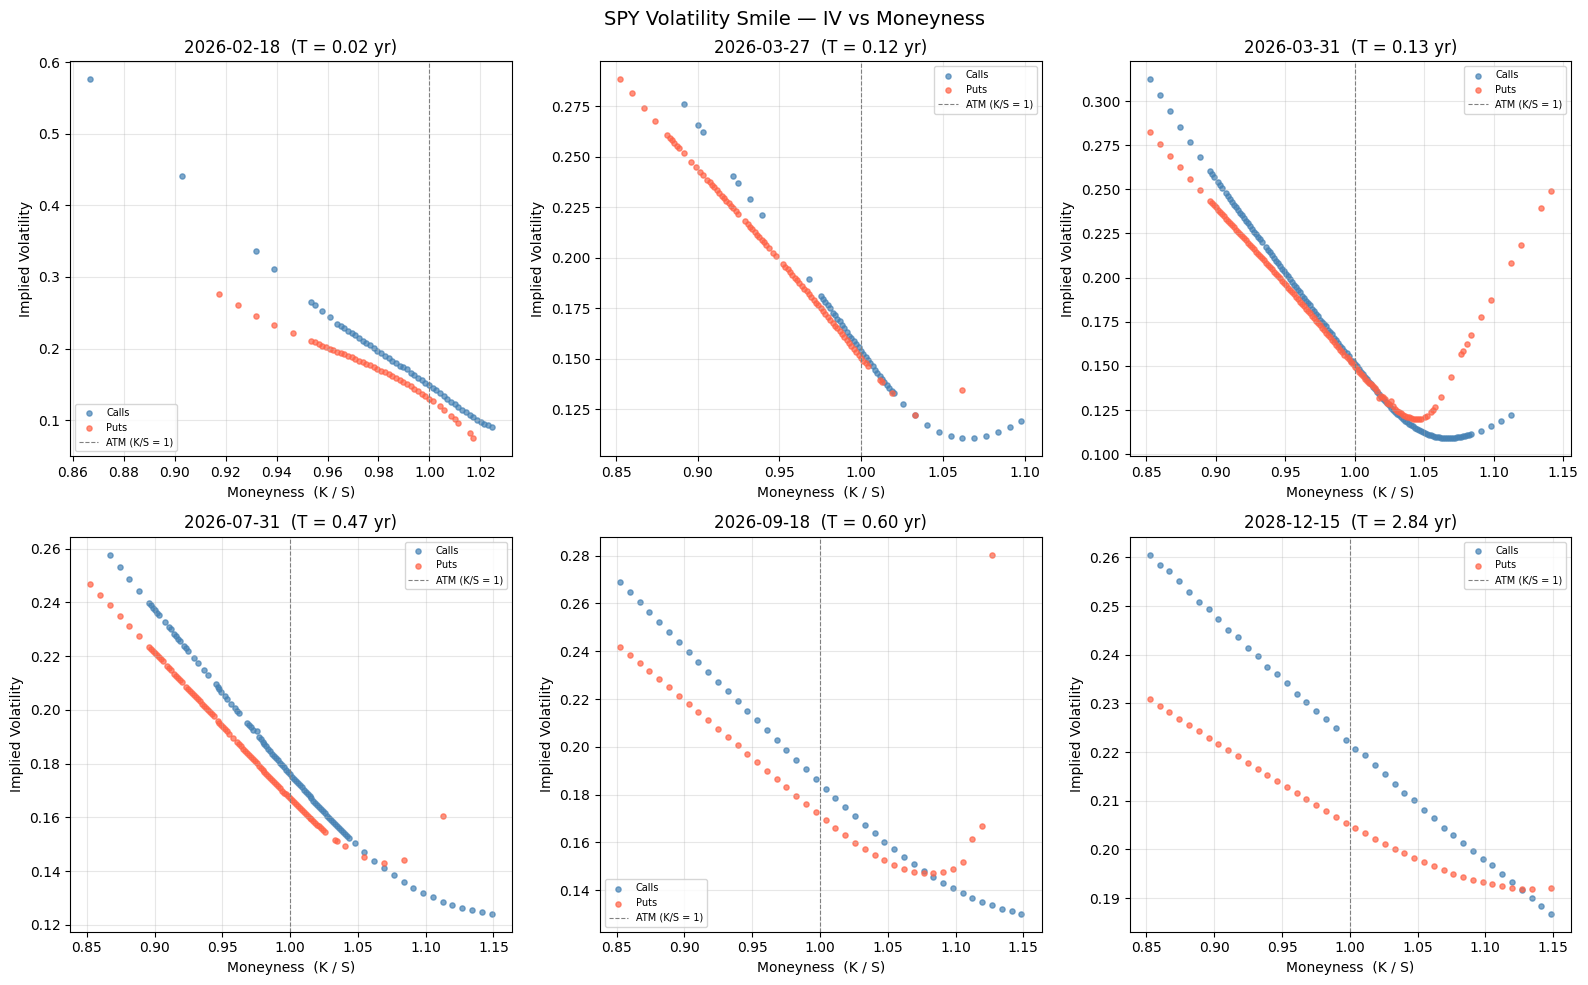

In [7]:
expiries = sorted(df["expiry"].unique())
n = len(expiries)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, expiry in enumerate(expiries):
    ax = axes[i]
    sub = df[df["expiry"] == expiry]
    T_val = sub["T"].iloc[0]

    calls = sub[sub["option_type"] == "call"]
    puts = sub[sub["option_type"] == "put"]

    ax.scatter(calls["moneyness"], calls["iv"], s=14, alpha=0.7,
               label="Calls", color="steelblue")
    ax.scatter(puts["moneyness"], puts["iv"], s=14, alpha=0.7,
               label="Puts", color="tomato")

    ax.axvline(1.0, color="gray", ls="--", lw=0.8, label="ATM (K/S = 1)")

    ax.set_title(f"{expiry}  (T = {T_val:.2f} yr)")
    ax.set_xlabel("Moneyness  (K / S)")
    ax.set_ylabel("Implied Volatility")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("SPY Volatility Smile — IV vs Moneyness", fontsize=14)
plt.tight_layout()
plt.show()

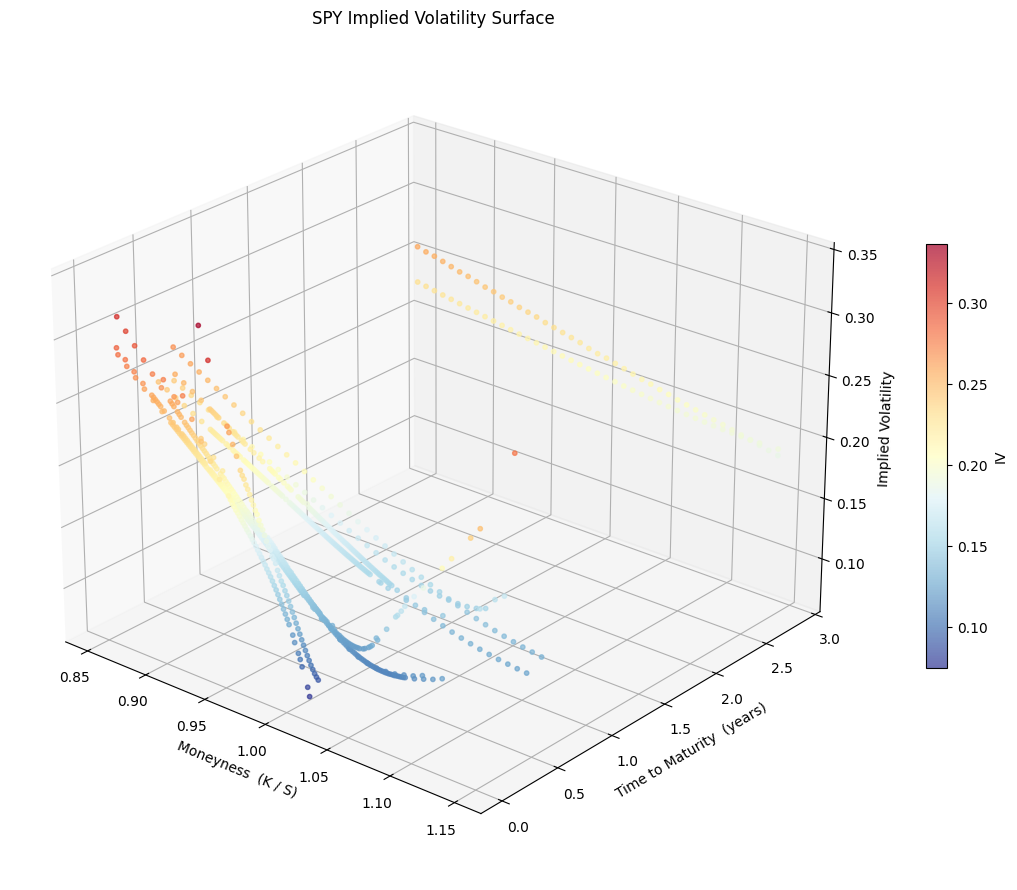

In [8]:
# Remove IV outliers (keep reasonable range)
iv_low, iv_high = df["iv"].quantile(0.01), df["iv"].quantile(0.99)
df_clean = df[(df["iv"] >= 0.05) & (df["iv"] <= 0.35)].copy()

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_clean["moneyness"], df_clean["T"], df_clean["iv"],
    c=df_clean["iv"], cmap="RdYlBu_r", s=10, alpha=0.7,
)

ax.set_xlabel("Moneyness  (K / S)")
ax.set_ylabel("Time to Maturity  (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("SPY Implied Volatility Surface")
fig.colorbar(sc, ax=ax, shrink=0.5, label="IV")
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

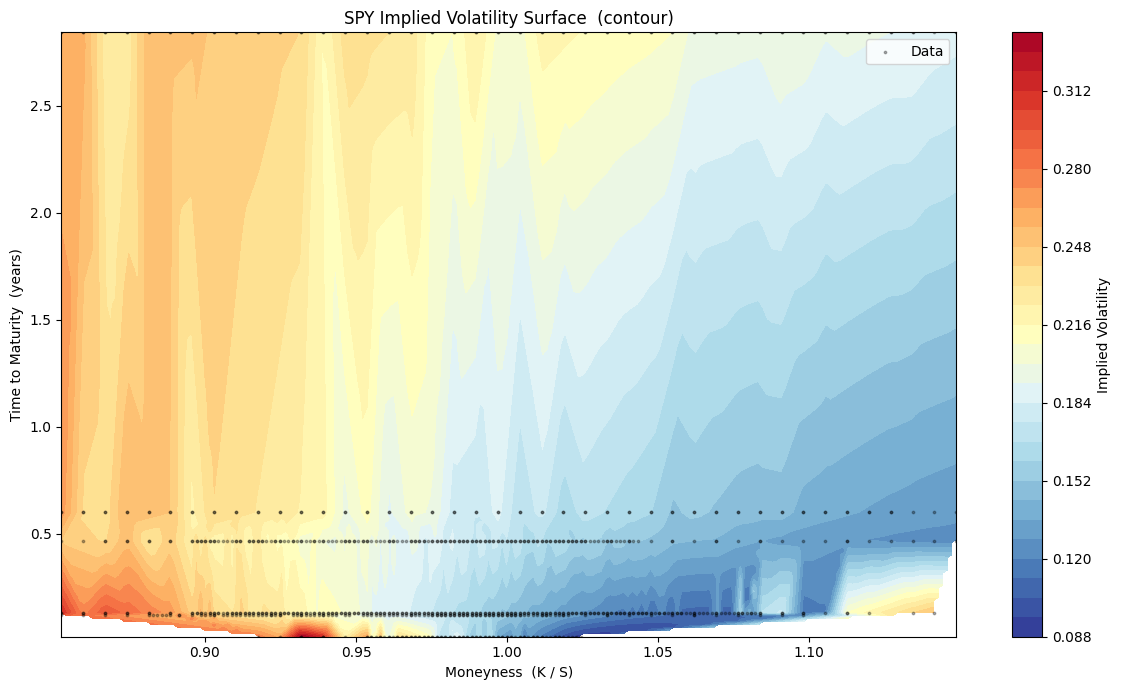

In [9]:
m_grid = np.linspace(df_clean["moneyness"].min(), df_clean["moneyness"].max(), 200)
t_grid = np.linspace(df_clean["T"].min(), df_clean["T"].max(), 200)
M, TAU = np.meshgrid(m_grid, t_grid)

IV_grid = griddata(
    points=(df_clean["moneyness"].values, df_clean["T"].values),
    values=df_clean["iv"].values,
    xi=(M, TAU),
    method="linear",          # linear instead of cubic — no oscillation across the T gap
)

fig, ax = plt.subplots(figsize=(12, 7))
cf = ax.contourf(M, TAU, IV_grid, levels=30, cmap="RdYlBu_r")
fig.colorbar(cf, ax=ax, label="Implied Volatility")

ax.scatter(df_clean["moneyness"], df_clean["T"], c="black", s=3, alpha=0.3, label="Data")

ax.set_xlabel("Moneyness  (K / S)")
ax.set_ylabel("Time to Maturity  (years)")
ax.set_title("SPY Implied Volatility Surface  (contour)")
ax.legend()
plt.tight_layout()
plt.show()

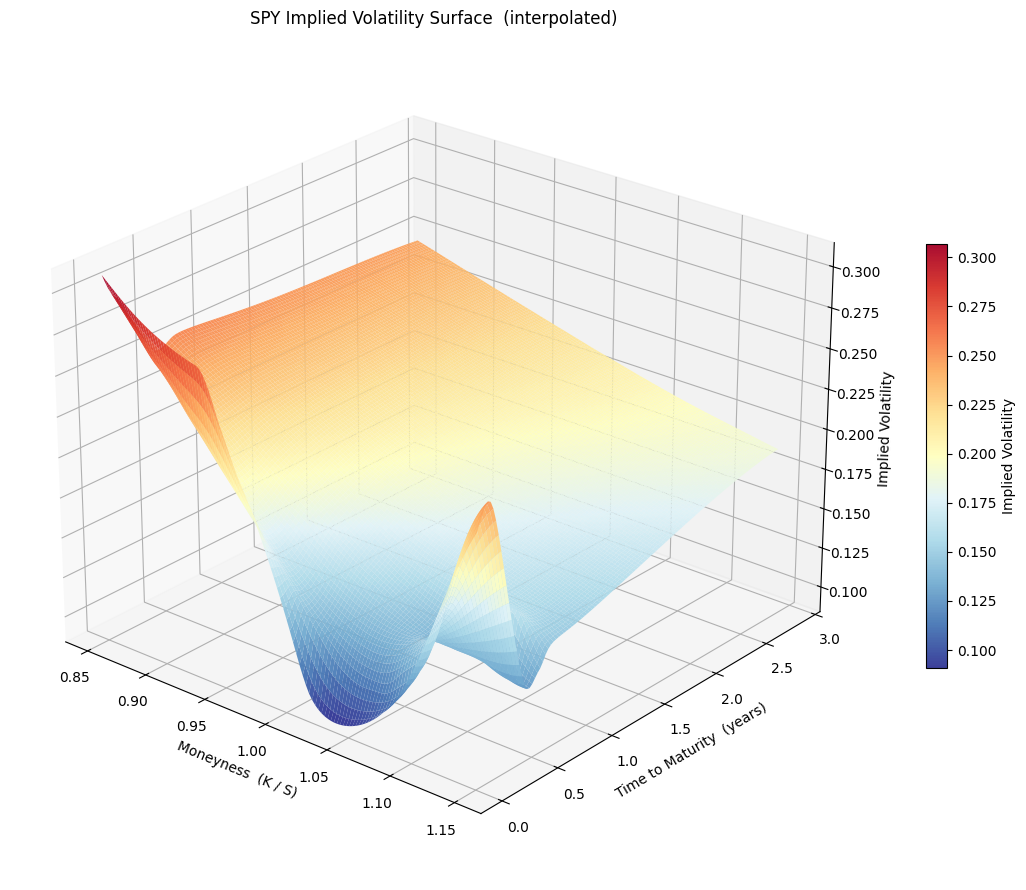

In [11]:
from scipy.interpolate import RBFInterpolator

# Normalize axes to similar scale (moneyness ~0.85-1.15, T ~0.02-2.84)
pts = np.column_stack([df_clean["moneyness"].values, df_clean["T"].values / 3.0])
vals = df_clean["iv"].values

rbf = RBFInterpolator(pts, vals, kernel="thin_plate_spline", smoothing=0.001)

m_grid_s = np.linspace(df_clean["moneyness"].min(), df_clean["moneyness"].max(), 120)
t_grid_s = np.linspace(df_clean["T"].min(), df_clean["T"].max(), 120)
Ms, Ts = np.meshgrid(m_grid_s, t_grid_s)

query = np.column_stack([Ms.ravel(), Ts.ravel() / 3.0])
IV_smooth = rbf(query).reshape(Ms.shape)
IV_smooth = np.clip(IV_smooth, 0.05, 0.35)

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    Ms, Ts, IV_smooth,
    cmap="RdYlBu_r", alpha=0.95,
    rstride=1, cstride=1, edgecolor="none",
    antialiased=True,
)

ax.set_xlabel("Moneyness  (K / S)")
ax.set_ylabel("Time to Maturity  (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("SPY Implied Volatility Surface  (interpolated)")
fig.colorbar(surf, ax=ax, shrink=0.5, label="Implied Volatility")
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

### Volatility Smile: Analysis and Financial Interpretation

**What we observe.** The plots above reveal a pattern in SPY implied volatility that directly contradicts the Black-Scholes assumption of constant volatility. Across all six expirations, IV is not flat — it rises steeply as moneyness decreases (K/S < 1, lower strikes), falling more gently for higher strikes (K/S > 1). This asymmetric shape is known as the volatility skew, characteristic of equity index options. Note that by put-call parity, calls and puts at the same strike and expiration yield nearly identical implied volatilities, so the smile is a property of the strike, not of the option type.

**Inconsistency with Black-Scholes.** In the BS framework, volatility is a single constant that applies equally to all strikes and expirations. If this were true, our implied volatility solver would return the same sigma for every option at a given expiration — a flat horizontal line. Instead, we observe IV ranging from approximately 12% (deep OTM calls / deep ITM puts) to approximately 28% (deep OTM puts / deep ITM calls) within a single expiry. This means the market prices options as if the underlying follows a distribution with fatter left tails than the lognormal distribution assumed by BS.

**Financial explanations for the skew:**

- Leverage effect: when an index declines, the economy's effective leverage increases, making equity riskier and driving realized volatility higher. This negative correlation between returns and volatility (empirically rho is approximately -0.7 for SPY) naturally generates higher IV at lower strikes.

- Crash risk premium: after the 1987 Black Monday crash, market participants recognized that extreme downside moves are far more probable than the lognormal model predicts. Investors pay a premium for OTM puts as portfolio insurance, pushing their prices — and thus implied volatilities — above what a constant-volatility model would suggest.

- Supply and demand for protection: institutional investors (pension funds, mutual funds) systematically buy OTM puts to hedge equity portfolios. Market makers who sell these puts demand compensation for bearing left-tail risk, inflating the left wing of the smile.

**Term structure of the smile.** A second important pattern is visible across expirations: the smile flattens as T increases. Short-term options (T = 0.02y) exhibit an extremely steep skew, while long-dated options (T = 2.84y) show a milder slope. This occurs because short-term options are highly sensitive to the current (possibly transient) level of volatility, while long-term options reflect a blend of possible future volatility regimes, averaging out the extremes.

These observations motivate the use of stochastic volatility models (Phase 3–4), which can generate the skew endogenously rather than requiring a different sigma for each strike.